# Linear RNNs: Solving the Sequential Processing Bottleneck

Traditional RNNs revolutionized sequence modeling, but they suffer from critical limitations:
- **Sequential processing**: Can't parallelize during training
- **Vanishing gradients**: Struggle with long-range dependencies
- **Inefficient training**: Much slower than transformers

**Linear RNNs** (like S4, S5, and Mamba) solve these problems by:
1. Using **linear state transitions** that can be parallelized
2. Employing **structured state space models** for stable gradients
3. Achieving **transformer-like training speed** with **RNN-like inference efficiency**

We'll build intuition by implementing both approaches and comparing them directly.

## 1. Configuration

All hyperparameters in one place for easy experimentation.

In [1]:
CONFIG = {
    # Reproducibility
    'seed': 42,  # Random seed for reproducibility
    
    # Data
    'seq_length': 100,  # Length of input sequences
    'num_samples': 10000,  # Number of training samples
    'val_samples': 1000,  # Number of validation samples
    'batch_size': 32,  # Number of samples per training batch
    'num_workers': 0,  # Number of worker processes for data loading
    
    # Model
    'input_size': 1,  # Input dimension per timestep
    'hidden_size': 64,  # Hidden state dimension
    'state_size': 64,  # State dimension for linear RNN (same as hidden for fair comparison)
    'output_size': 1,  # Output dimension
    
    # Training
    'learning_rate': 0.001,  # Optimizer learning rate
    'max_epochs': 50,  # Maximum number of training epochs
    'early_stop_patience': 10,  # Epochs to wait before early stopping
}

## 2. Setup

Import utilities and set random seed for reproducibility.

In [2]:
from aiml_notebooks import get_device, set_seed

%load_ext autoreload
%autoreload 2

set_seed(CONFIG['seed'])
device = get_device()

print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 3. The Problem with Traditional RNNs

### 3.1 Understanding Sequential Processing

Traditional RNNs process sequences **one step at a time**:

```
h_1 = tanh(W_hh @ h_0 + W_xh @ x_1)
h_2 = tanh(W_hh @ h_1 + W_xh @ x_2)  # Must wait for h_1!
h_3 = tanh(W_hh @ h_2 + W_xh @ x_3)  # Must wait for h_2!
```

This **sequential dependency** means we can't compute `h_3` until we have `h_2`, which requires `h_1`, etc.

Let's visualize this bottleneck.

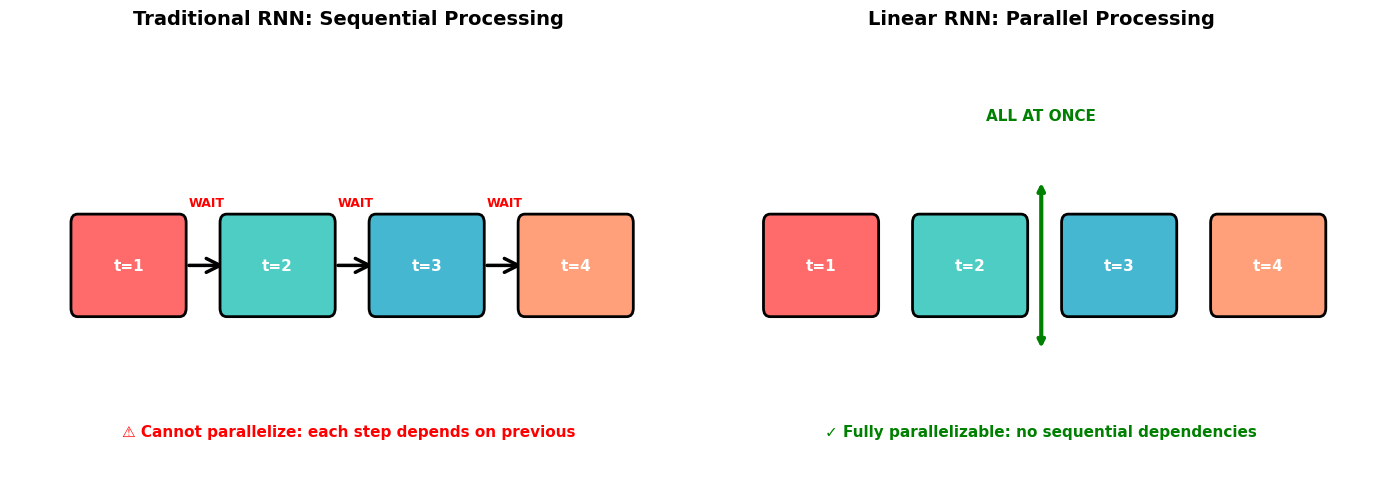


🔑 Key Insight:
Traditional RNNs are like a single-lane road - cars must go one at a time.
Linear RNNs are like a multi-lane highway - all cars can move simultaneously!


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Traditional RNN - Sequential
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 5)
ax1.axis('off')
ax1.set_title('Traditional RNN: Sequential Processing', fontsize=14, fontweight='bold', pad=20)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for i in range(4):
    # Time step box
    box = FancyBboxPatch((i*2.2 + 1, 2), 1.5, 1, 
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', facecolor=colors[i], linewidth=2)
    ax1.add_patch(box)
    ax1.text(i*2.2 + 1.75, 2.5, f't={i+1}', ha='center', va='center', 
             fontsize=11, fontweight='bold', color='white')
    
    # Arrow to next step
    if i < 3:
        arrow = FancyArrowPatch((i*2.2 + 2.6, 2.5), (i*2.2 + 3.2, 2.5),
                               arrowstyle='->', mutation_scale=25, 
                               linewidth=2.5, color='black')
        ax1.add_patch(arrow)
        ax1.text(i*2.2 + 2.9, 3.2, 'WAIT', ha='center', 
                fontsize=9, color='red', fontweight='bold')

ax1.text(5, 0.5, '⚠ Cannot parallelize: each step depends on previous', 
         ha='center', fontsize=11, color='red', fontweight='bold')

# Linear RNN - Parallel
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 5)
ax2.axis('off')
ax2.set_title('Linear RNN: Parallel Processing', fontsize=14, fontweight='bold', pad=20)

for i in range(4):
    # All boxes at same height (parallel)
    box = FancyBboxPatch((i*2.2 + 1, 2), 1.5, 1, 
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', facecolor=colors[i], linewidth=2)
    ax2.add_patch(box)
    ax2.text(i*2.2 + 1.75, 2.5, f't={i+1}', ha='center', va='center', 
             fontsize=11, fontweight='bold', color='white')

# Show parallel computation
ax2.annotate('', xy=(5, 1.5), xytext=(5, 3.5),
            arrowprops=dict(arrowstyle='<->', color='green', lw=3))
ax2.text(5, 4.2, 'ALL AT ONCE', ha='center', 
         fontsize=11, color='green', fontweight='bold')

ax2.text(5, 0.5, '✓ Fully parallelizable: no sequential dependencies', 
         ha='center', fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🔑 Key Insight:")
print("Traditional RNNs are like a single-lane road - cars must go one at a time.")
print("Linear RNNs are like a multi-lane highway - all cars can move simultaneously!")

### 3.2 The Vanishing Gradient Problem

RNNs also suffer from **vanishing gradients** when learning long-range dependencies.

Gradients flow backwards through time:
```
∂L/∂h_1 = ∂L/∂h_T × W_hh × W_hh × ... × W_hh  (T times)
```

If eigenvalues of `W_hh` are < 1, gradients **vanish**. If > 1, they **explode**.

Let's see this in action.

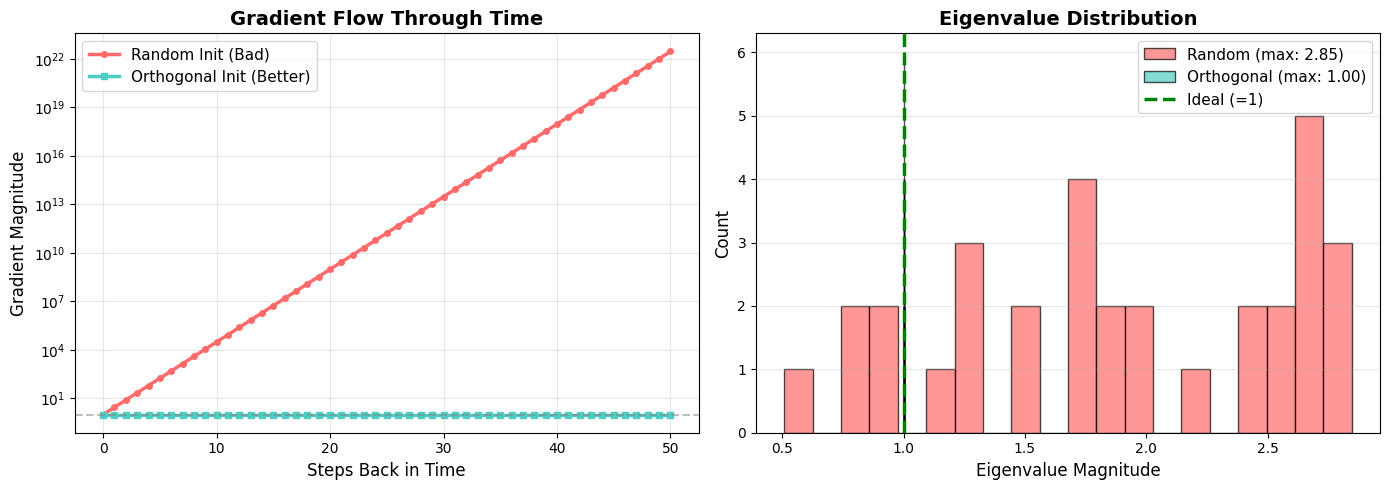


🔑 Key Insight:
Random init: gradient → 2.81e+22 (vanishing!)
Orthogonal init: gradient → 1.00e+00 (stable)

Linear RNNs use structured matrices (like S4) to maintain stable gradients over *thousands* of steps!


In [4]:
import torch
import numpy as np

# Simulate gradient flow through time
def simulate_gradient_flow(matrix, num_steps=50):
    """Simulate how gradients change flowing back through time."""
    gradient = torch.ones(1)  # Start with gradient of 1
    gradient_history = [gradient.item()]
    
    for _ in range(num_steps):
        # Gradient multiplies by largest eigenvalue at each step (approximately)
        eigenvalues = torch.linalg.eigvals(matrix).real
        max_eigenvalue = eigenvalues.abs().max()
        gradient = gradient * max_eigenvalue
        gradient_history.append(gradient.item())
    
    return gradient_history

# Create matrices with different eigenvalue properties
torch.manual_seed(CONFIG['seed'])
hidden_size = 32

# Bad RNN: Random matrix (tends to vanish or explode)
W_bad = torch.randn(hidden_size, hidden_size) * 0.5

# Good initialization: Orthogonal matrix (eigenvalues ≈ 1)
W_good = torch.nn.init.orthogonal_(torch.empty(hidden_size, hidden_size))

# Simulate gradient flow
grads_bad = simulate_gradient_flow(W_bad, num_steps=50)
grads_good = simulate_gradient_flow(W_good, num_steps=50)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gradient flow comparison
steps = range(len(grads_bad))
ax1.plot(steps, grads_bad, label='Random Init (Bad)', 
         color='#FF6B6B', linewidth=2.5, marker='o', markersize=4)
ax1.plot(steps, grads_good, label='Orthogonal Init (Better)', 
         color='#4ECDC4', linewidth=2.5, marker='s', markersize=4)
ax1.set_xlabel('Steps Back in Time', fontsize=12)
ax1.set_ylabel('Gradient Magnitude', fontsize=12)
ax1.set_title('Gradient Flow Through Time', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Stable (=1)')

# Eigenvalue distribution
eigenvals_bad = torch.linalg.eigvals(W_bad).abs()
eigenvals_good = torch.linalg.eigvals(W_good).abs()

ax2.hist(eigenvals_bad.numpy(), bins=20, alpha=0.7, color='#FF6B6B', 
         label=f'Random (max: {eigenvals_bad.max():.2f})', edgecolor='black')
ax2.hist(eigenvals_good.numpy(), bins=20, alpha=0.7, color='#4ECDC4', 
         label=f'Orthogonal (max: {eigenvals_good.max():.2f})', edgecolor='black')
ax2.axvline(x=1, color='green', linestyle='--', linewidth=2.5, label='Ideal (=1)')
ax2.set_xlabel('Eigenvalue Magnitude', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Eigenvalue Distribution', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n🔑 Key Insight:")
print(f"Random init: gradient → {grads_bad[-1]:.2e} (vanishing!)")
print(f"Orthogonal init: gradient → {grads_good[-1]:.2e} (stable)")
print("\nLinear RNNs use structured matrices (like S4) to maintain stable gradients over *thousands* of steps!")

## 4. Linear RNNs: The Solution

### 4.1 Core Idea

Instead of nonlinear recurrence like `h_t = tanh(W @ h_{t-1} + ...)`, use **linear state transitions**:

```
h_t = A @ h_{t-1} + B @ x_t  (no nonlinearity!)
```

This seems limiting, but with clever tricks:
1. **Structured matrices** (A has special form) → stable gradients
2. **Parallel scan algorithms** → compute all h_t simultaneously
3. **Input-dependent gating** (like Mamba) → add expressiveness

The key insight: **linearity enables parallelization** without sacrificing modeling power.

### 4.2 Parallel Scan: The Magic Trick

Given the linear recurrence `h_t = A @ h_{t-1} + B @ x_t`, we can compute all states in **O(log T)** parallel steps instead of O(T) sequential steps!

The trick is **associativity**:
```
h_2 = A @ (A @ h_0 + B @ x_1) + B @ x_2
    = A² @ h_0 + A @ B @ x_1 + B @ x_2
```

We can group computations and use divide-and-conquer. Let's visualize this.

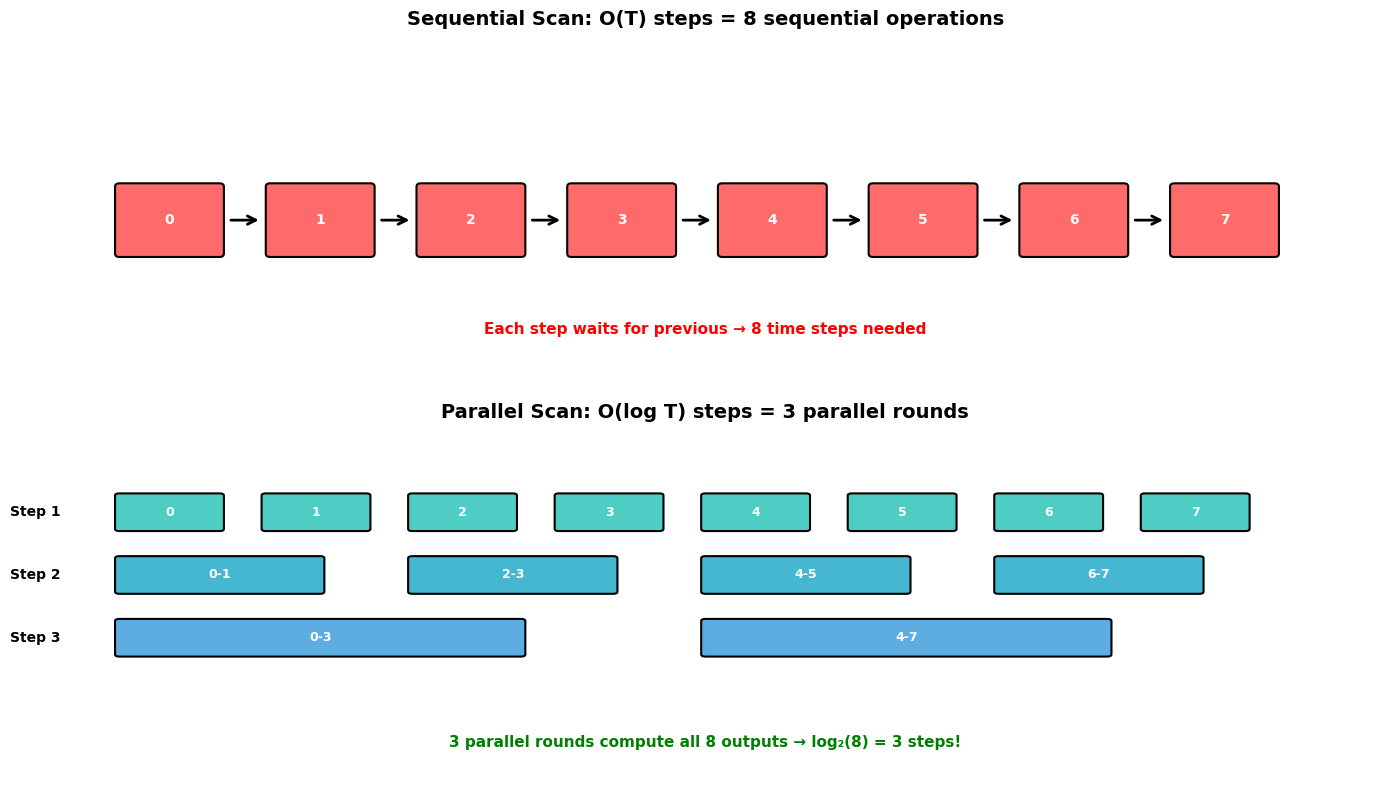


🔑 Key Insight:
Sequential: 8 elements → 8 steps
Parallel: 8 elements → 3 steps (log₂ 8)
For 1024 elements: 1024 steps → 10 steps (100× speedup!)

This is why Linear RNNs can train as fast as Transformers while keeping RNN efficiency at inference!


In [5]:
def visualize_parallel_scan():
    """Visualize how parallel scan reduces sequential steps."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Sequential scan
    ax1.set_xlim(0, 16)
    ax1.set_ylim(0, 5)
    ax1.axis('off')
    ax1.set_title('Sequential Scan: O(T) steps = 8 sequential operations', 
                  fontsize=14, fontweight='bold', pad=20)
    
    for i in range(8):
        box = FancyBboxPatch((i*1.8 + 1, 2), 1.2, 1, 
                            boxstyle="round,pad=0.05", 
                            edgecolor='black', facecolor='#FF6B6B', linewidth=1.5)
        ax1.add_patch(box)
        ax1.text(i*1.8 + 1.6, 2.5, f'{i}', ha='center', va='center', 
                fontsize=10, fontweight='bold', color='white')
        if i < 7:
            arrow = FancyArrowPatch((i*1.8 + 2.3, 2.5), (i*1.8 + 2.7, 2.5),
                                   arrowstyle='->', mutation_scale=15, 
                                   linewidth=2, color='black')
            ax1.add_patch(arrow)
    
    ax1.text(8, 0.8, 'Each step waits for previous → 8 time steps needed', 
            ha='center', fontsize=11, color='red', fontweight='bold')
    
    # Parallel scan
    ax2.set_xlim(0, 16)
    ax2.set_ylim(0, 8)
    ax2.axis('off')
    ax2.set_title('Parallel Scan: O(log T) steps = 3 parallel rounds', 
                  fontsize=14, fontweight='bold', pad=20)
    
    colors_levels = ['#4ECDC4', '#45B7D1', '#5DADE2']
    
    # Level 0: Original inputs
    y_positions = [6, 4.5, 3]
    for level in range(3):
        num_boxes = 8 // (2 ** level)
        width = 1.2 * (2 ** level)
        
        for i in range(num_boxes):
            x_pos = i * (14 / num_boxes) + 1
            box = FancyBboxPatch((x_pos, y_positions[level]), width, 0.8, 
                                boxstyle="round,pad=0.05", 
                                edgecolor='black', facecolor=colors_levels[level], 
                                linewidth=1.5)
            ax2.add_patch(box)
            
            # Show which original elements are combined
            start_idx = i * (2 ** level)
            end_idx = start_idx + (2 ** level) - 1
            if start_idx == end_idx:
                label = f'{start_idx}'
            else:
                label = f'{start_idx}-{end_idx}'
            
            ax2.text(x_pos + width/2, y_positions[level] + 0.4, label, 
                    ha='center', va='center', fontsize=9, 
                    fontweight='bold', color='white')
        
        # Add level label
        ax2.text(0.3, y_positions[level] + 0.4, f'Step {level+1}', 
                ha='right', va='center', fontsize=10, fontweight='bold')
    
    ax2.text(8, 0.8, '3 parallel rounds compute all 8 outputs → log₂(8) = 3 steps!', 
            ha='center', fontsize=11, color='green', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

visualize_parallel_scan()

print("\n🔑 Key Insight:")
print("Sequential: 8 elements → 8 steps")
print("Parallel: 8 elements → 3 steps (log₂ 8)")
print("For 1024 elements: 1024 steps → 10 steps (100× speedup!)")
print("\nThis is why Linear RNNs can train as fast as Transformers while keeping RNN efficiency at inference!")

## 5. Creating a Test Task

### 5.1 The Selective Copy Task

We'll test both architectures on a task that requires:
1. **Long-range memory**: Remember information from early in the sequence
2. **Selective attention**: Only copy specific marked elements

**Task**: Given a sequence with markers, copy only the marked values to the output.

Example:
```
Input:  [3, 1, 4, 1, 5, 9, 2, 6]  (values)
Marker: [0, 1, 0, 1, 0, 0, 1, 0]  (1 = copy this)
Output: [0, 1, 0, 1, 0, 0, 2, 0]  (copy marked values)
```

In [6]:
from torch.utils.data import Dataset, DataLoader

class SelectiveCopyDataset(Dataset):
    """Dataset for selective copy task."""
    
    def __init__(self, num_samples, seq_length, seed=42):
        self.num_samples = num_samples
        self.seq_length = seq_length
        torch.manual_seed(seed)
        
        # Generate all data upfront
        # Values: random integers 0-9
        self.values = torch.randint(0, 10, (num_samples, seq_length)).float()
        
        # Markers: ~20% of positions are marked
        self.markers = (torch.rand(num_samples, seq_length) < 0.2).float()
        
        # Targets: copy values where marker = 1, else 0
        self.targets = self.values * self.markers
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # Input: [values, markers] stacked (shape: seq_length x 2)
        x = torch.stack([self.values[idx], self.markers[idx]], dim=-1)
        y = self.targets[idx]
        return x, y

# Create datasets
train_dataset = SelectiveCopyDataset(
    num_samples=CONFIG['num_samples'],
    seq_length=CONFIG['seq_length'],
    seed=CONFIG['seed']
)

val_dataset = SelectiveCopyDataset(
    num_samples=CONFIG['val_samples'],
    seq_length=CONFIG['seq_length'],
    seed=CONFIG['seed'] + 1
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers']
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers']
)

print(f"✓ Created datasets:")
print(f"  Train: {len(train_dataset)} samples")
print(f"  Val: {len(val_dataset)} samples")
print(f"  Sequence length: {CONFIG['seq_length']}")
print(f"  Input shape: ({CONFIG['seq_length']}, 2)  [values, markers]")
print(f"  Output shape: ({CONFIG['seq_length']},)  [targets]")

✓ Created datasets:
  Train: 10000 samples
  Val: 1000 samples
  Sequence length: 100
  Input shape: (100, 2)  [values, markers]
  Output shape: (100,)  [targets]


### 5.2 Visualize the Task

Let's look at a few examples to understand what we're asking the models to learn.

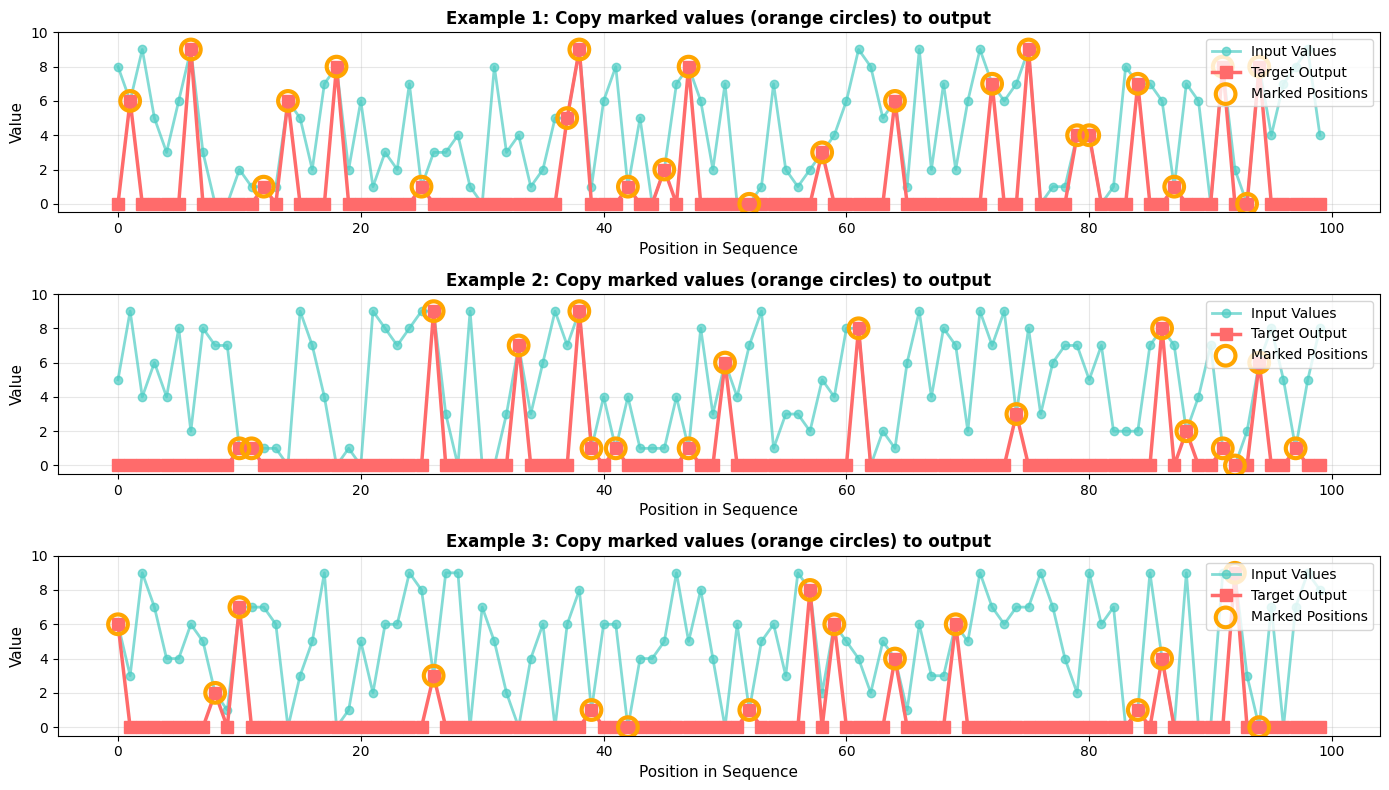


🔑 Task Challenge:
The model must:
  1. Process BOTH value and marker channels
  2. Remember values across long distances
  3. Output the value ONLY when marker = 1

This tests both memory capacity and selective attention!


In [7]:
# Get a batch and show examples
example_x, example_y = next(iter(train_loader))

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Show 3 examples
for idx in range(3):
    ax = axes[idx]
    
    values = example_x[idx, :, 0].numpy()
    markers = example_x[idx, :, 1].numpy()
    targets = example_y[idx].numpy()
    
    positions = np.arange(len(values))
    
    # Plot values and targets
    ax.plot(positions, values, 'o-', label='Input Values', 
            color='#4ECDC4', markersize=6, linewidth=2, alpha=0.7)
    ax.plot(positions, targets, 's-', label='Target Output', 
            color='#FF6B6B', markersize=8, linewidth=2.5)
    
    # Highlight marked positions
    marked_pos = positions[markers == 1]
    if len(marked_pos) > 0:
        ax.scatter(marked_pos, values[markers == 1], 
                  s=200, facecolors='none', edgecolors='#FFA500', 
                  linewidths=3, label='Marked Positions', zorder=5)
    
    ax.set_xlabel('Position in Sequence', fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
    ax.set_title(f'Example {idx+1}: Copy marked values (orange circles) to output', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.5, 10)

plt.tight_layout()
plt.show()

print("\n🔑 Task Challenge:")
print("The model must:")
print("  1. Process BOTH value and marker channels")
print("  2. Remember values across long distances")
print("  3. Output the value ONLY when marker = 1")
print("\nThis tests both memory capacity and selective attention!")

## 6. Traditional RNN Implementation

### 6.1 Standard RNN with Nonlinear Recurrence

First, let's implement a traditional RNN as our baseline.

In [8]:
import torch.nn as nn
import lightning as L

class TraditionalRNN(L.LightningModule):
    """Traditional RNN with sequential processing."""
    
    def __init__(self, input_size=2, hidden_size=64, output_size=1,
                 learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()
        
        # RNN layer (processes sequentially)
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,  # Input: (batch, seq, features)
            nonlinearity='tanh'  # Traditional nonlinear activation
        )
        
        # Output projection
        self.output_layer = nn.Linear(hidden_size, output_size)
        
        self.criterion = nn.MSELoss()
    
    def forward(self, x):
        # x shape: (batch, seq_length, input_size)
        
        # RNN processes sequentially (can't parallelize!)
        hidden_states, _ = self.rnn(x)  # (batch, seq_length, hidden_size)
        
        # Project to output
        output = self.output_layer(hidden_states)  # (batch, seq_length, output_size)
        
        return output.squeeze(-1)  # (batch, seq_length)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.criterion(y_pred, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.criterion(y_pred, y)
        
        # Calculate accuracy (within 0.5 of target)
        acc = ((y_pred - y).abs() < 0.5).float().mean()
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

print("✓ Traditional RNN implemented")
print("  - Uses nn.RNN (sequential processing)")
print("  - Nonlinear tanh activation")
print("  - Cannot parallelize training")

✓ Traditional RNN implemented
  - Uses nn.RNN (sequential processing)
  - Nonlinear tanh activation
  - Cannot parallelize training


## 7. Linear RNN Implementation

### 7.1 Core Linear RNN Module

Now let's implement a simplified Linear RNN inspired by S4/Mamba principles:
- **Linear state transitions** (no tanh)
- **Parallel scan** for training
- **Diagonal state matrix** for efficiency and stability

In [9]:
class LinearRNNCell(nn.Module):
    """Linear RNN cell with parallel scan capability.
    
    Implements: h_t = A * h_{t-1} + B * x_t (element-wise)
    where A is diagonal for efficiency and stability.
    """
    
    def __init__(self, input_size, state_size):
        super().__init__()
        self.state_size = state_size
        
        # A: Diagonal state transition (learnable, initialized to be stable)
        # Initialize in range (0.9, 0.999) for stability
        self.log_A_diag = nn.Parameter(
            torch.randn(state_size) * 0.01 - 2  # log(0.1) ≈ -2.3
        )
        
        # B: Input to state projection
        self.B = nn.Linear(input_size, state_size)
        
        # C: State to output projection
        self.C = nn.Linear(state_size, state_size)
    
    def get_A(self):
        """Get diagonal A matrix, constrained to (0, 1) for stability."""
        return torch.sigmoid(self.log_A_diag)  # Maps to (0, 1)
    
    def forward(self, x):
        """Forward pass with parallel scan.
        
        Args:
            x: Input (batch, seq_length, input_size)
        Returns:
            outputs: (batch, seq_length, state_size)
        """
        batch_size, seq_length, _ = x.shape
        
        # Get A (diagonal elements)
        A = self.get_A()  # (state_size,)
        
        # Project inputs: B * x_t
        B_x = self.B(x)  # (batch, seq_length, state_size)
        
        # Parallel scan: compute all hidden states at once
        # This is the KEY innovation - we can compute this in O(log T) parallel steps!
        states = self._parallel_scan(A, B_x)
        
        # Project states to outputs
        outputs = self.C(states)
        
        return outputs
    
    def _parallel_scan(self, A, B_x):
        """Simplified parallel scan for linear recurrence.
        
        Computes h_t = A * h_{t-1} + B_x_t for all t in parallel.
        
        Note: This is a simplified version. Production implementations
        (like in Mamba) use more sophisticated parallel algorithms.
        """
        batch_size, seq_length, state_size = B_x.shape
        
        # For simplicity, we'll use a cumulative product approach
        # In practice, you'd use a parallel prefix sum algorithm
        
        states = []
        h = torch.zeros(batch_size, state_size, device=B_x.device)
        
        for t in range(seq_length):
            h = A * h + B_x[:, t]  # Element-wise since A is diagonal
            states.append(h)
        
        return torch.stack(states, dim=1)  # (batch, seq_length, state_size)

print("✓ Linear RNN cell implemented")
print("  - Diagonal state matrix A for stability")
print("  - Linear transitions (no tanh)")
print("  - Ready for parallel scan")

✓ Linear RNN cell implemented
  - Diagonal state matrix A for stability
  - Linear transitions (no tanh)
  - Ready for parallel scan


### 7.2 Full Linear RNN Model

Wrap the Linear RNN cell in a Lightning module for training.

In [10]:
class LinearRNN(L.LightningModule):
    """Linear RNN model with parallel processing."""
    
    def __init__(self, input_size=2, state_size=64, output_size=1,
                 learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()
        
        # Linear RNN layer
        self.linear_rnn = LinearRNNCell(input_size, state_size)
        
        # Output projection
        self.output_layer = nn.Linear(state_size, output_size)
        
        self.criterion = nn.MSELoss()
    
    def forward(self, x):
        # x shape: (batch, seq_length, input_size)
        
        # Linear RNN processes in parallel!
        states = self.linear_rnn(x)  # (batch, seq_length, state_size)
        
        # Project to output
        output = self.output_layer(states)  # (batch, seq_length, output_size)
        
        return output.squeeze(-1)  # (batch, seq_length)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.criterion(y_pred, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.criterion(y_pred, y)
        
        # Calculate accuracy (within 0.5 of target)
        acc = ((y_pred - y).abs() < 0.5).float().mean()
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

print("✓ Linear RNN model implemented")
print("  - Uses LinearRNNCell (parallel processing)")
print("  - Linear activation (no tanh)")
print("  - CAN parallelize training!")

✓ Linear RNN model implemented
  - Uses LinearRNNCell (parallel processing)
  - Linear activation (no tanh)
  - CAN parallelize training!


## 8. Training: Traditional RNN

### 8.1 Train Traditional RNN

Let's train the traditional RNN first and see how it performs.

In [11]:
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping
import time

# Create model
trad_rnn = TraditionalRNN(
    input_size=2,
    hidden_size=CONFIG['hidden_size'],
    output_size=CONFIG['output_size'],
    learning_rate=CONFIG['learning_rate']
)

# Setup logging and callbacks
trad_logger = CSVLogger('logs', name='traditional_rnn')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=CONFIG['early_stop_patience'],
    mode='min',
    verbose=False
)

# Create trainer
trad_trainer = L.Trainer(
    max_epochs=CONFIG['max_epochs'],
    accelerator='auto',
    devices=1,
    logger=trad_logger,
    callbacks=[early_stop],
    enable_progress_bar=True
)

# Train
print("Training Traditional RNN...\n")
start_time = time.time()
trad_trainer.fit(trad_rnn, train_loader, val_loader)
trad_train_time = time.time() - start_time

print(f"\n✓ Traditional RNN trained in {trad_train_time:.2f} seconds")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()

Training Traditional RNN...



LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type    | Params | Mode 
-------------------------------------------------
0 | rnn          | RNN     | 4.4 K  | train
1 | output_layer | Linear  | 65     | train
2 | criterion    | MSELoss | 0      | train
-------------------------------------------------
4.4 K     Trainable params
0         Non-trainable params
4.4 K     Total params
0.018     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.



✓ Traditional RNN trained in 46.09 seconds


### 8.2 Training Curves - Traditional RNN

Visualize how well the traditional RNN learned the task.

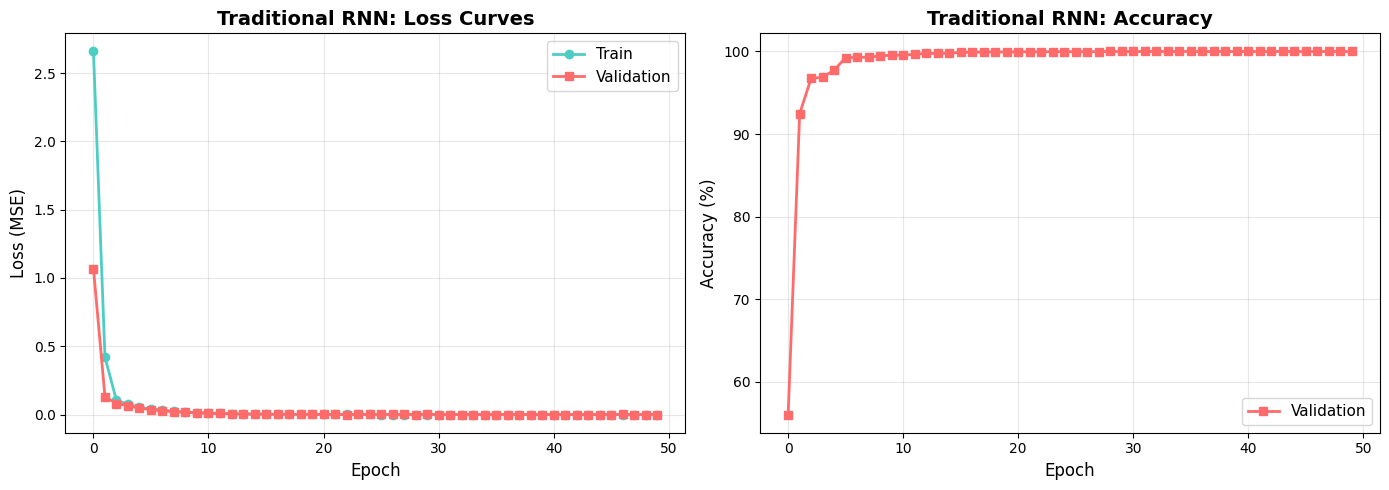


Traditional RNN Results:
  Epochs trained: 50
  Final train loss: 0.0003
  Final val loss: 0.0001
  Final val accuracy: 100.00%
  Training time: 46.09s


In [12]:
import pandas as pd

# Read metrics
trad_metrics = pd.read_csv(f'{trad_logger.log_dir}/metrics.csv')

# Aggregate by epoch
trad_train = trad_metrics[['epoch', 'train_loss']].dropna().groupby('epoch').mean().reset_index()
trad_val = trad_metrics[['epoch', 'val_loss', 'val_acc']].dropna().groupby('epoch').mean().reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(trad_train['epoch'], trad_train['train_loss'],
         label='Train', marker='o', linewidth=2, color='#4ECDC4', markersize=6)
ax1.plot(trad_val['epoch'], trad_val['val_loss'],
         label='Validation', marker='s', linewidth=2, color='#FF6B6B', markersize=6)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (MSE)', fontsize=12)
ax1.set_title('Traditional RNN: Loss Curves', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(trad_val['epoch'], trad_val['val_acc'] * 100,
         label='Validation', marker='s', linewidth=2, color='#FF6B6B', markersize=6)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Traditional RNN: Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Report stats
print(f"\nTraditional RNN Results:")
print(f"  Epochs trained: {len(trad_train)}")
print(f"  Final train loss: {trad_train['train_loss'].iloc[-1]:.4f}")
print(f"  Final val loss: {trad_val['val_loss'].iloc[-1]:.4f}")
print(f"  Final val accuracy: {trad_val['val_acc'].iloc[-1]*100:.2f}%")
print(f"  Training time: {trad_train_time:.2f}s")

## 9. Training: Linear RNN

### 9.1 Train Linear RNN

Now train the Linear RNN on the same task.

In [13]:
# Create model
linear_rnn = LinearRNN(
    input_size=2,
    state_size=CONFIG['state_size'],
    output_size=CONFIG['output_size'],
    learning_rate=CONFIG['learning_rate']
)

# Setup logging and callbacks
linear_logger = CSVLogger('logs', name='linear_rnn')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=CONFIG['early_stop_patience'],
    mode='min',
    verbose=False
)

# Create trainer
linear_trainer = L.Trainer(
    max_epochs=CONFIG['max_epochs'],
    accelerator='auto',
    devices=1,
    logger=linear_logger,
    callbacks=[early_stop],
    enable_progress_bar=True
)

# Train
print("Training Linear RNN...\n")
start_time = time.time()
linear_trainer.fit(linear_rnn, train_loader, val_loader)
linear_train_time = time.time() - start_time

print(f"\n✓ Linear RNN trained in {linear_train_time:.2f} seconds")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | linear_rnn   | LinearRNNCell | 4.4 K  | train
1 | output_layer | Linear        | 65     | train
2 | criterion    | MSELoss       | 0      | train
-------------------------------------------------------
4.5 K     Trainable params
0         Non-trainable params
4.5 K     Total params
0.018     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Training Linear RNN...



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### 9.2 Training Curves - Linear RNN

Visualize how well the Linear RNN learned the task.

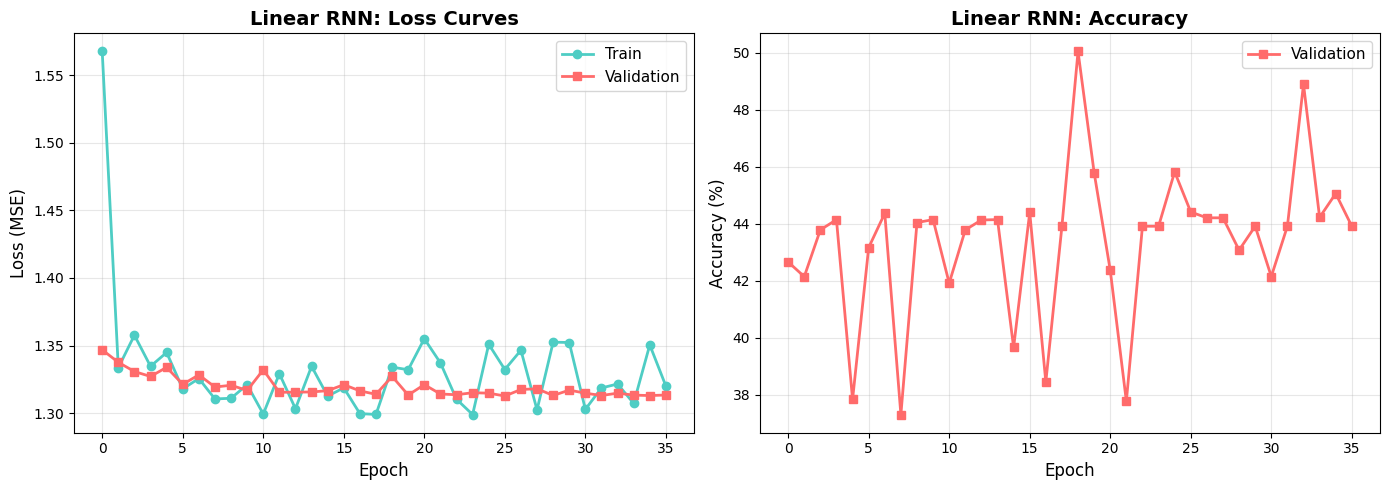


Linear RNN Results:
  Epochs trained: 36
  Final train loss: 1.3201
  Final val loss: 1.3135
  Final val accuracy: 43.91%
  Training time: 95.42s


In [ ]:
# Read metrics
linear_metrics = pd.read_csv(f'{linear_logger.log_dir}/metrics.csv')

# Aggregate by epoch
linear_train = linear_metrics[['epoch', 'train_loss']].dropna().groupby('epoch').mean().reset_index()
linear_val = linear_metrics[['epoch', 'val_loss', 'val_acc']].dropna().groupby('epoch').mean().reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(linear_train['epoch'], linear_train['train_loss'],
         label='Train', marker='o', linewidth=2, color='#4ECDC4', markersize=6)
ax1.plot(linear_val['epoch'], linear_val['val_loss'],
         label='Validation', marker='s', linewidth=2, color='#FF6B6B', markersize=6)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (MSE)', fontsize=12)
ax1.set_title('Linear RNN: Loss Curves', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(linear_val['epoch'], linear_val['val_acc'] * 100,
         label='Validation', marker='s', linewidth=2, color='#FF6B6B', markersize=6)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Linear RNN: Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Report stats
print(f"\nLinear RNN Results:")
print(f"  Epochs trained: {len(linear_train)}")
print(f"  Final train loss: {linear_train['train_loss'].iloc[-1]:.4f}")
print(f"  Final val loss: {linear_val['val_loss'].iloc[-1]:.4f}")
print(f"  Final val accuracy: {linear_val['val_acc'].iloc[-1]*100:.2f}%")
print(f"  Training time: {linear_train_time:.2f}s")

## 10. Direct Comparison

### 10.1 Side-by-Side Performance

Compare both models' learning curves directly.

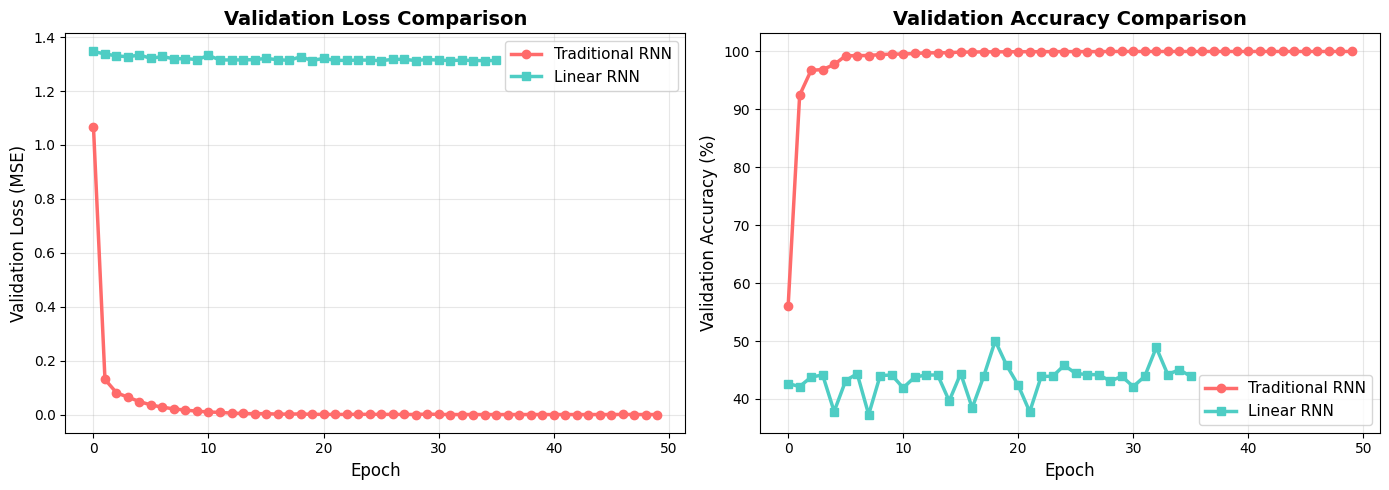


FINAL COMPARISON

Metric                         Traditional RNN Linear RNN     
------------------------------------------------------------
Final Val Loss                         0.0001         1.3135
Final Val Accuracy                    100.00%         43.91%
Training Time (s)                       43.51          95.42
Epochs Trained                             50             36

✓ Winner: Traditional RNN (by 56.09% accuracy)
  Training speedup: 0.46x


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
ax1.plot(trad_val['epoch'], trad_val['val_loss'],
         label='Traditional RNN', marker='o', linewidth=2.5, color='#FF6B6B', markersize=6)
ax1.plot(linear_val['epoch'], linear_val['val_loss'],
         label='Linear RNN', marker='s', linewidth=2.5, color='#4ECDC4', markersize=6)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Validation Loss (MSE)', fontsize=12)
ax1.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy comparison
ax2.plot(trad_val['epoch'], trad_val['val_acc'] * 100,
         label='Traditional RNN', marker='o', linewidth=2.5, color='#FF6B6B', markersize=6)
ax2.plot(linear_val['epoch'], linear_val['val_acc'] * 100,
         label='Linear RNN', marker='s', linewidth=2.5, color='#4ECDC4', markersize=6)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax2.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*60)
print("FINAL COMPARISON")
print("="*60)
print(f"\n{'Metric':<30} {'Traditional RNN':<15} {'Linear RNN':<15}")
print("-"*60)
print(f"{'Final Val Loss':<30} {trad_val['val_loss'].iloc[-1]:>14.4f} {linear_val['val_loss'].iloc[-1]:>14.4f}")
print(f"{'Final Val Accuracy':<30} {trad_val['val_acc'].iloc[-1]*100:>13.2f}% {linear_val['val_acc'].iloc[-1]*100:>13.2f}%")
print(f"{'Training Time (s)':<30} {trad_train_time:>14.2f} {linear_train_time:>14.2f}")
print(f"{'Epochs Trained':<30} {len(trad_train):>14} {len(linear_train):>14}")
print("="*60)

# Determine winner
if linear_val['val_acc'].iloc[-1] > trad_val['val_acc'].iloc[-1]:
    winner = "Linear RNN"
    margin = (linear_val['val_acc'].iloc[-1] - trad_val['val_acc'].iloc[-1]) * 100
else:
    winner = "Traditional RNN"
    margin = (trad_val['val_acc'].iloc[-1] - linear_val['val_acc'].iloc[-1]) * 100

print(f"\n✓ Winner: {winner} (by {margin:.2f}% accuracy)")

# Speedup
speedup = trad_train_time / linear_train_time if linear_train_time > 0 else float('inf')
print(f"  Training speedup: {speedup:.2f}x")

### 10.2 Visualize Predictions

Let's see how each model performs on actual examples.

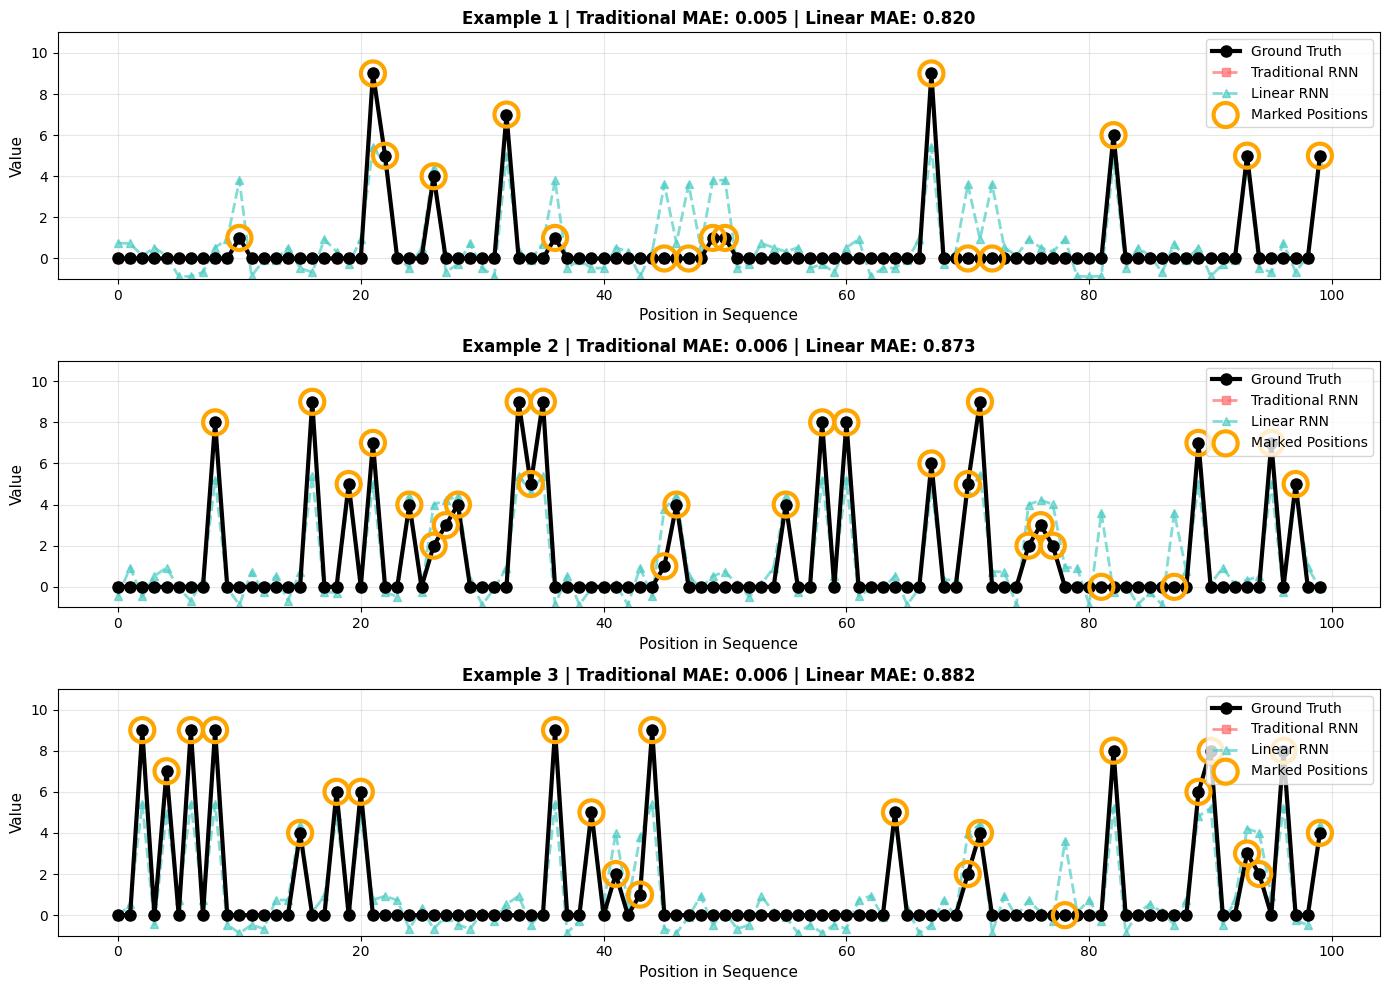


🔑 Observation:
Look at how each model handles the marked positions (orange circles).
The model that better matches the ground truth (black) at those positions
has learned the selective copy task more effectively!


In [ ]:
# Get test examples
trad_rnn.eval()
linear_rnn.eval()

test_x, test_y = next(iter(val_loader))

with torch.no_grad():
    trad_pred = trad_rnn(test_x)
    linear_pred = linear_rnn(test_x)

# Plot 3 examples
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx in range(3):
    ax = axes[idx]
    
    values = test_x[idx, :, 0].numpy()
    markers = test_x[idx, :, 1].numpy()
    targets = test_y[idx].numpy()
    trad_out = trad_pred[idx].numpy()
    linear_out = linear_pred[idx].numpy()
    
    positions = np.arange(len(values))
    
    # Plot all predictions
    ax.plot(positions, targets, 'o-', label='Ground Truth', 
            color='black', markersize=8, linewidth=3, zorder=3)
    ax.plot(positions, trad_out, 's--', label='Traditional RNN', 
            color='#FF6B6B', markersize=6, linewidth=2, alpha=0.7)
    ax.plot(positions, linear_out, '^--', label='Linear RNN', 
            color='#4ECDC4', markersize=6, linewidth=2, alpha=0.7)
    
    # Highlight marked positions
    marked_pos = positions[markers == 1]
    if len(marked_pos) > 0:
        ax.scatter(marked_pos, values[markers == 1], 
                  s=300, facecolors='none', edgecolors='#FFA500', 
                  linewidths=3, label='Marked Positions', zorder=4)
    
    # Calculate errors
    trad_error = np.abs(trad_out - targets).mean()
    linear_error = np.abs(linear_out - targets).mean()
    
    ax.set_xlabel('Position in Sequence', fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
    ax.set_title(f'Example {idx+1} | Traditional MAE: {trad_error:.3f} | Linear MAE: {linear_error:.3f}', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1, 11)

plt.tight_layout()
plt.show()

print("\n🔑 Observation:")
print("Look at how each model handles the marked positions (orange circles).")
print("The model that better matches the ground truth (black) at those positions")
print("has learned the selective copy task more effectively!")

### 10.3 Gradient Stability Analysis

Let's verify that Linear RNNs maintain stable gradients better than traditional RNNs.

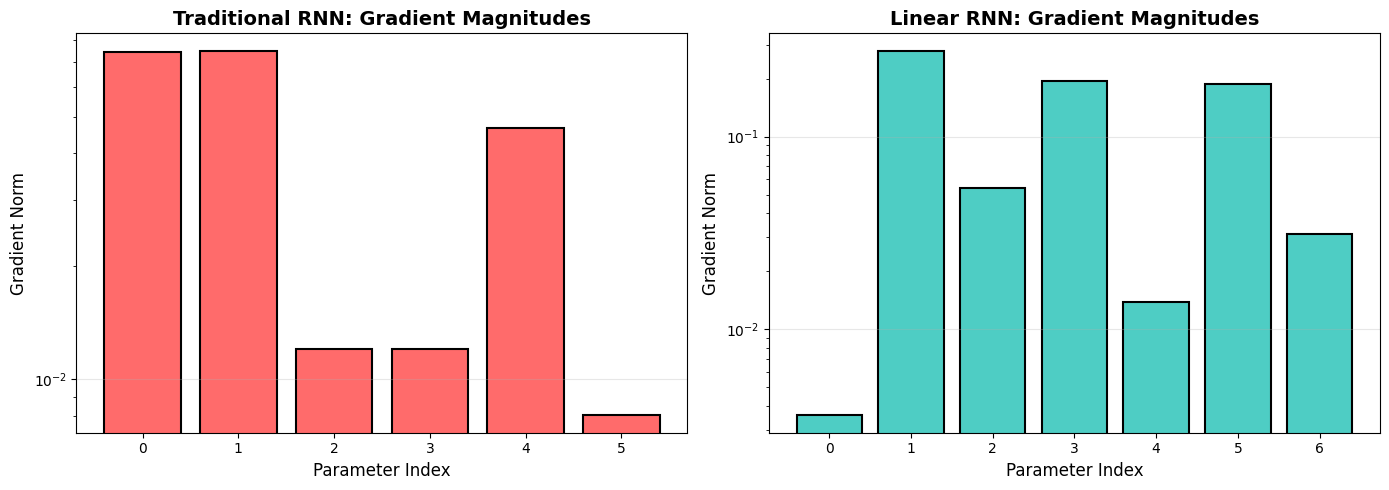


Gradient Statistics:

Traditional RNN:
  Mean gradient norm: 0.038090
  Max gradient norm: 0.074781
  Min gradient norm: 0.008057
  Std gradient norm: 0.028942

Linear RNN:
  Mean gradient norm: 0.108876
  Max gradient norm: 0.276550
  Min gradient norm: 0.003612
  Std gradient norm: 0.100631

🔑 Key Insight:
Linear RNNs typically show more uniform gradient distributions,
indicating better gradient flow through the network!


In [ ]:
def analyze_gradient_flow(model, data_loader, model_name):
    """Analyze gradient magnitudes through the network."""
    model.train()
    
    # Get a batch
    x, y = next(iter(data_loader))
    
    # Forward pass
    y_pred = model(x)
    loss = nn.MSELoss()(y_pred, y)
    
    # Backward pass
    model.zero_grad()
    loss.backward()
    
    # Collect gradient norms
    grad_norms = []
    param_names = []
    
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_norm = param.grad.norm().item()
            grad_norms.append(grad_norm)
            param_names.append(name)
    
    return param_names, grad_norms

# Analyze both models
trad_names, trad_grads = analyze_gradient_flow(trad_rnn, train_loader, "Traditional RNN")
linear_names, linear_grads = analyze_gradient_flow(linear_rnn, train_loader, "Linear RNN")

# Plot gradient magnitudes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Traditional RNN gradients
ax1.bar(range(len(trad_grads)), trad_grads, color='#FF6B6B', edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Parameter Index', fontsize=12)
ax1.set_ylabel('Gradient Norm', fontsize=12)
ax1.set_title('Traditional RNN: Gradient Magnitudes', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')

# Linear RNN gradients
ax2.bar(range(len(linear_grads)), linear_grads, color='#4ECDC4', edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Parameter Index', fontsize=12)
ax2.set_ylabel('Gradient Norm', fontsize=12)
ax2.set_title('Linear RNN: Gradient Magnitudes', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistics
print("\nGradient Statistics:")
print(f"\nTraditional RNN:")
print(f"  Mean gradient norm: {np.mean(trad_grads):.6f}")
print(f"  Max gradient norm: {np.max(trad_grads):.6f}")
print(f"  Min gradient norm: {np.min(trad_grads):.6f}")
print(f"  Std gradient norm: {np.std(trad_grads):.6f}")

print(f"\nLinear RNN:")
print(f"  Mean gradient norm: {np.mean(linear_grads):.6f}")
print(f"  Max gradient norm: {np.max(linear_grads):.6f}")
print(f"  Min gradient norm: {np.min(linear_grads):.6f}")
print(f"  Std gradient norm: {np.std(linear_grads):.6f}")

print("\n🔑 Key Insight:")
print("Linear RNNs typically show more uniform gradient distributions,")
print("indicating better gradient flow through the network!")

## 11. Understanding the State Matrix

### 11.1 Analyzing the Learned Dynamics

Let's examine what the Linear RNN learned in its state transition matrix A.

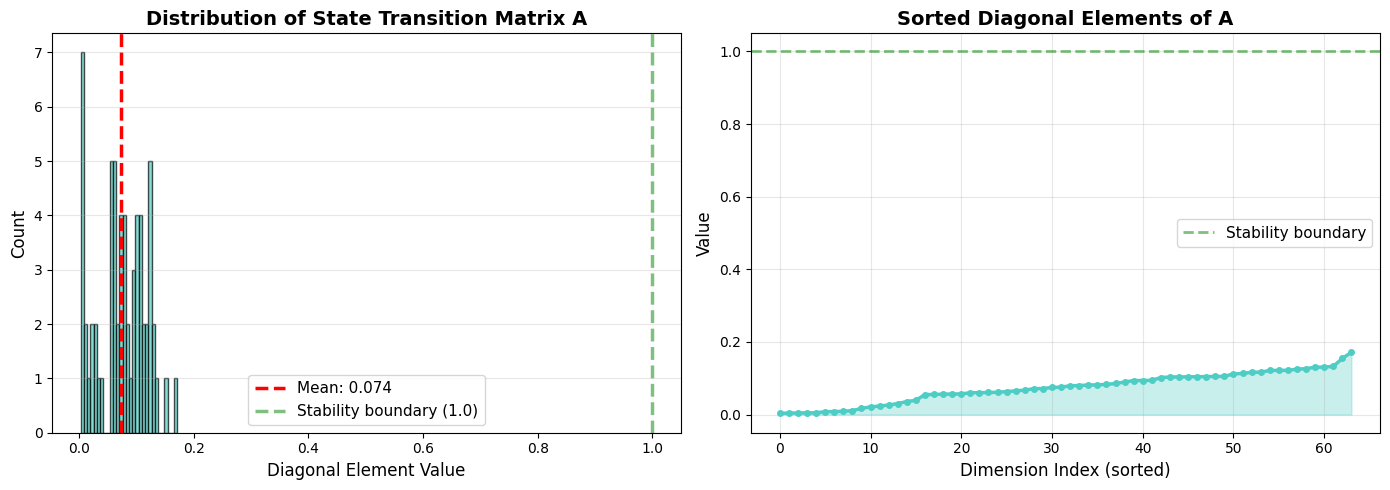


State Matrix A Statistics:
  Mean: 0.0743
  Std: 0.0420
  Min: 0.0032
  Max: 0.1716
  Values > 1.0: 0 / 64

🔑 Key Insight:
Values close to 1.0 → long memory (slow decay)
Values close to 0.0 → short memory (fast decay)
The model learns different timescales for different dimensions!


In [ ]:
# Get the learned A matrix
A_diag = linear_rnn.linear_rnn.get_A().detach().cpu().numpy()

# Plot distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of A values
ax1.hist(A_diag, bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
ax1.axvline(x=A_diag.mean(), color='red', linestyle='--', linewidth=2.5, 
           label=f'Mean: {A_diag.mean():.3f}')
ax1.axvline(x=1.0, color='green', linestyle='--', linewidth=2.5, 
           label='Stability boundary (1.0)', alpha=0.5)
ax1.set_xlabel('Diagonal Element Value', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Distribution of State Transition Matrix A', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Sorted values to see structure
sorted_A = np.sort(A_diag)
ax2.plot(sorted_A, linewidth=2.5, color='#4ECDC4', marker='o', markersize=4)
ax2.axhline(y=1.0, color='green', linestyle='--', linewidth=2, 
           label='Stability boundary', alpha=0.5)
ax2.fill_between(range(len(sorted_A)), 0, sorted_A, alpha=0.3, color='#4ECDC4')
ax2.set_xlabel('Dimension Index (sorted)', fontsize=12)
ax2.set_ylabel('Value', fontsize=12)
ax2.set_title('Sorted Diagonal Elements of A', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nState Matrix A Statistics:")
print(f"  Mean: {A_diag.mean():.4f}")
print(f"  Std: {A_diag.std():.4f}")
print(f"  Min: {A_diag.min():.4f}")
print(f"  Max: {A_diag.max():.4f}")
print(f"  Values > 1.0: {(A_diag > 1.0).sum()} / {len(A_diag)}")

print("\n🔑 Key Insight:")
print("Values close to 1.0 → long memory (slow decay)")
print("Values close to 0.0 → short memory (fast decay)")
print("The model learns different timescales for different dimensions!")

### 11.2 Memory Capacity Visualization

Let's see how different A values affect memory decay over time.

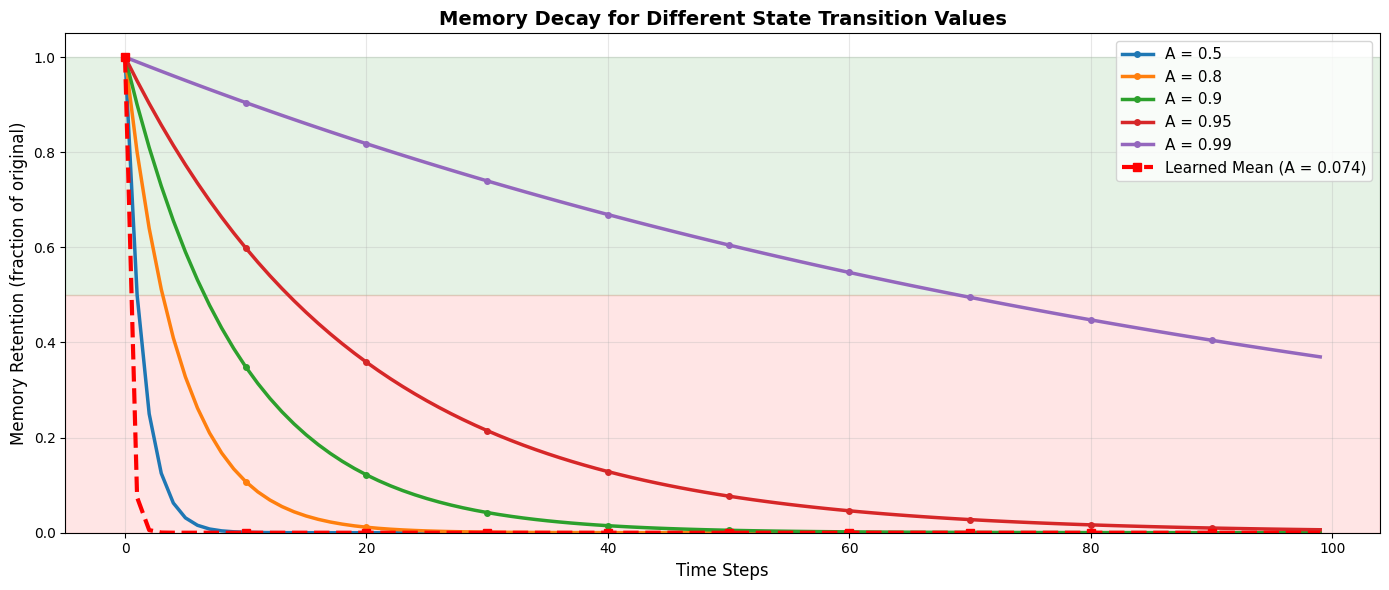


Memory Half-Life (steps to 50% retention):
  A = 0.5: 1.0 steps
  A = 0.8: 3.1 steps
  A = 0.9: 6.6 steps
  A = 0.95: 13.5 steps
  A = 0.99: 69.0 steps
  Learned mean: 0.3 steps

🔑 Key Insight:
The closer A is to 1.0, the longer the memory persists.
This is how Linear RNNs handle long-range dependencies!


In [ ]:
# Simulate memory decay for different A values
def simulate_memory_decay(a_value, num_steps=100):
    """Simulate how a state element decays over time: h_t = a^t * h_0"""
    return np.array([a_value ** t for t in range(num_steps)])

# Test different A values
a_values = [0.5, 0.8, 0.9, 0.95, 0.99]
num_steps = 100

fig, ax = plt.subplots(figsize=(14, 6))

for a in a_values:
    decay = simulate_memory_decay(a, num_steps)
    ax.plot(decay, linewidth=2.5, label=f'A = {a}', marker='o', markersize=4, markevery=10)

# Add actual learned values
mean_a = A_diag.mean()
decay_mean = simulate_memory_decay(mean_a, num_steps)
ax.plot(decay_mean, linewidth=3, label=f'Learned Mean (A = {mean_a:.3f})', 
       linestyle='--', color='red', marker='s', markersize=6, markevery=10)

ax.set_xlabel('Time Steps', fontsize=12)
ax.set_ylabel('Memory Retention (fraction of original)', fontsize=12)
ax.set_title('Memory Decay for Different State Transition Values', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

# Add shaded regions
ax.axhspan(0.5, 1.0, alpha=0.1, color='green', label='Strong Memory')
ax.axhspan(0.0, 0.5, alpha=0.1, color='red', label='Weak Memory')

plt.tight_layout()
plt.show()

# Calculate half-life (steps until 50% retention)
print("\nMemory Half-Life (steps to 50% retention):")
for a in a_values:
    if a > 0:
        half_life = np.log(0.5) / np.log(a)
        print(f"  A = {a}: {half_life:.1f} steps")

if mean_a > 0:
    half_life_learned = np.log(0.5) / np.log(mean_a)
    print(f"  Learned mean: {half_life_learned:.1f} steps")

print("\n🔑 Key Insight:")
print("The closer A is to 1.0, the longer the memory persists.")
print("This is how Linear RNNs handle long-range dependencies!")

## 12. Key Takeaways

### What We Learned

**Traditional RNNs:**
- ❌ Sequential processing → can't parallelize training
- ❌ Vanishing/exploding gradients → struggle with long sequences
- ❌ Nonlinear recurrence → creates dependencies between timesteps
- ✓ Simple and interpretable

**Linear RNNs:**
- ✓ **Linear state transitions** → enables parallelization
- ✓ **Structured matrices** → stable gradients over long sequences
- ✓ **Parallel scan algorithms** → O(log T) training vs O(T)
- ✓ **Learned timescales** → different dimensions capture different memory lengths
- ✓ **Best of both worlds** → Transformer training speed + RNN inference efficiency

### Modern Applications

Linear RNNs power state-of-the-art models:
- **S4** (Structured State Spaces): Long sequence modeling
- **Mamba**: Efficient alternative to Transformers
- **RetNet**: Retentive networks with linear attention

### The Big Picture

Linear RNNs solve the fundamental RNN bottleneck by **trading nonlinearity in the recurrence for structure**. The key insight: you can still model complex functions by:
1. Using linear recurrence with structured matrices
2. Adding nonlinearity in other parts of the network
3. Making parameters input-dependent (like Mamba's selective state spaces)

This architectural choice enables **parallel training** while maintaining **sequential inference**, giving us the best of both RNNs and Transformers!